In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam (1).csv


In [11]:
import pandas as pd
df = pd.read_csv("spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [12]:
df = df[['v1', 'v2']]
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
df.shape

(5572, 2)

In [15]:
df.isnull().sum()

,0
label,0
message,0


In [16]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [17]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


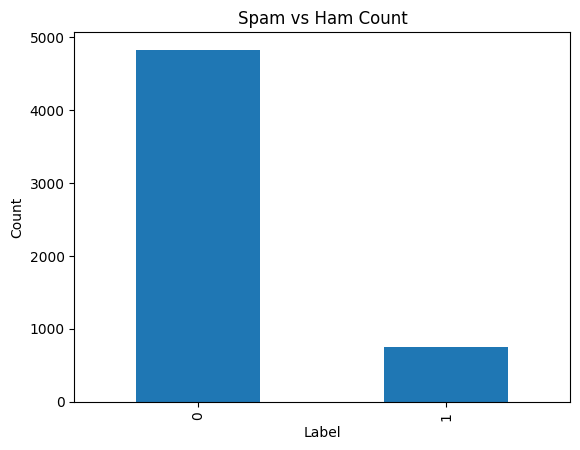

In [18]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Count")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [20]:
vectorizer = TfidfVectorizer()

In [21]:
X = vectorizer.fit_transform(df['message'])

In [22]:
y = df['label']

In [23]:
print(X.shape)


(5572, 8672)


In [24]:
print(X.shape)

(5572, 8672)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4457, 8672)
X_test : (1115, 8672)
y_train: (4457,)
y_test : (1115,)


In [27]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression()
model1.fit(X_train, y_train)

LogisticRegression()

In [28]:
pred1 = model1.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, pred1))
print("Precision:", precision_score(y_test, pred1))
print("Recall   :", recall_score(y_test, pred1))
print("F1 Score :", f1_score(y_test, pred1))

Accuracy : 0.9632286995515695
Precision: 1.0
Recall   : 0.7266666666666667
F1 Score : 0.8416988416988417


In [30]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(random_state=42)
model2.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [31]:
pred2 = model2.predict(X_test)

In [32]:
print("Accuracy :", accuracy_score(y_test, pred2))
print("Precision:", precision_score(y_test, pred2))
print("Recall   :", recall_score(y_test, pred2))
print("F1 Score :", f1_score(y_test, pred2))

Accuracy : 0.9766816143497757
Precision: 1.0
Recall   : 0.8266666666666667
F1 Score : 0.9051094890510949


In [33]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model2, X, y, cv=5, scoring='accuracy')
print(cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

[0.97757848 0.98026906 0.97576302 0.96947935 0.97755835]
Average CV Accuracy: 0.9761296503530283


In [34]:
from sklearn.metrics import roc_auc_score

probs = model2.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, probs)

print("ROC-AUC:", roc)

ROC-AUC: 0.9867806563039725
